# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [1]:
# import thu vien
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


## Tải dữ liệu

In [2]:
# doc du lieu
BASE_DIR = str(PROJECT_ROOT)

train_df = pd.read_csv(f"{BASE_DIR}/data/processed/train_processed.csv")
val_df = pd.read_csv(f"{BASE_DIR}/data/processed/val_processed.csv")
test_df = pd.read_csv(f"{BASE_DIR}/data/processed/test_processed.csv")

TEXT_COL = "text_clean"
LABEL_COL = "label_id"

train_df.shape, val_df.shape, test_df.shape


((24046, 5), (2672, 5), (6680, 5))

In [3]:
# xem du lieu
train_df[[TEXT_COL, LABEL_COL]].head()


,text_clean,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


## Mô hình TF-IDF + SVM

In [4]:
# tach text va nhan
X_train = train_df[TEXT_COL].fillna("").astype(str)
y_train = train_df[LABEL_COL].astype(int)

X_val = val_df[TEXT_COL].fillna("").astype(str)
y_val = val_df[LABEL_COL].astype(int)

X_test = test_df[TEXT_COL].fillna("").astype(str)
y_test = test_df[LABEL_COL].astype(int)


In [5]:
# ham tinh metric
def get_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision_macro": round(precision, 4),
        "recall_macro": round(recall, 4),
        "f1_macro": round(f1, 4)
    }

tfidf_params = {
    "ngram_range": (1, 2),
    "min_df": 3,
    "max_df": 0.95,
    "sublinear_tf": True,
    "max_features": 50000
}


In [6]:
# chon C tren tap val
c_values = [0.25, 0.5, 1.0, 2.0]
search_rows = []

for c in c_values:
    tfidf = TfidfVectorizer(**tfidf_params)
    X_train_vec = tfidf.fit_transform(X_train)
    X_val_vec = tfidf.transform(X_val)

    svm = LinearSVC(C=c, class_weight="balanced", max_iter=10000)
    svm.fit(X_train_vec, y_train)
    val_pred = svm.predict(X_val_vec)

    row = {"C": c}
    row.update(get_metrics(y_val, val_pred))
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(["f1_macro", "accuracy"], ascending=False)
best_c = search_df.iloc[0]["C"]

search_df.reset_index(drop=True).round(4)


,C,accuracy,precision_macro,recall_macro,f1_macro
0,1.00,0.8529,0.6355,0.6168,0.6244
1,0.25,0.8563,0.6481,0.6076,0.6213
2,2.00,0.8503,0.6301,0.6125,0.6201
3,0.50,0.8518,0.6303,0.6093,0.6163


## Đánh giá

In [7]:
# train lai voi train va val
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train_val = train_val_df[TEXT_COL].fillna("").astype(str)
y_train_val = train_val_df[LABEL_COL].astype(int)

tfidf = TfidfVectorizer(**tfidf_params)
X_train_val_vec = tfidf.fit_transform(X_train_val)
X_test_vec = tfidf.transform(X_test)

svm_model = LinearSVC(C=best_c, class_weight="balanced", max_iter=10000)
svm_model.fit(X_train_val_vec, y_train_val)

test_pred = svm_model.predict(X_test_vec)

metric_df = pd.DataFrame([{
    "model": "TF-IDF + SVM",
    "best_c": best_c,
    **get_metrics(y_test, test_pred)
}])

metric_df.round(4)


,model,best_c,accuracy,precision_macro,recall_macro,f1_macro
0,TF-IDF + SVM,1.0,0.8632,0.6522,0.6347,0.6427


In [8]:
# bao cao chi tiet
report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_pred,
        labels=[0, 1, 2],
        target_names=["CLEAN", "OFFENSIVE", "HATE"],
        output_dict=True,
        zero_division=0
    )
).T

report_df.round(4)


,precision,recall,f1-score,support
CLEAN,0.9272,0.9371,0.9321,5548.0000
OFFENSIVE,0.4661,0.4032,0.4324,444.0000
HATE,0.5631,0.5640,0.5635,688.0000
accuracy,0.8632,0.8632,0.8632,0.8632
macro avg,0.6522,0.6347,0.6427,6680.0000
weighted avg,0.8591,0.8632,0.8610,6680.0000


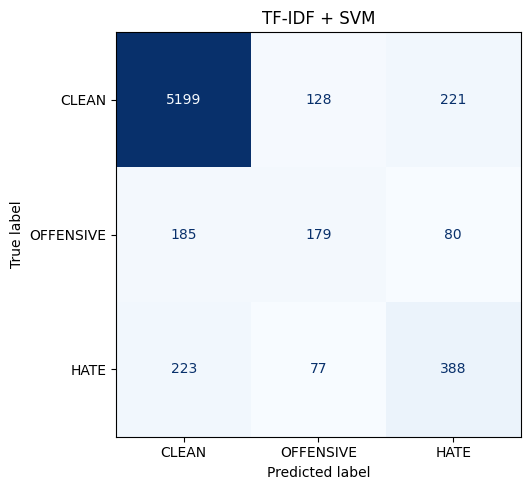

In [9]:
# ve confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    labels=[0, 1, 2],
    display_labels=["CLEAN", "OFFENSIVE", "HATE"],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("TF-IDF + SVM")
plt.tight_layout()
plt.show()


## Lưu kết quả

In [10]:
# luu ket qua
MODEL_DIR = f"{BASE_DIR}/outputs/models"
METRIC_DIR = f"{BASE_DIR}/outputs/results"
FIGURE_DIR = f"{BASE_DIR}/outputs/figures"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

metric_df.to_csv(f"{METRIC_DIR}/svm_metrics.csv", index=False)
report_df.to_csv(f"{METRIC_DIR}/svm_classification_report.csv")
fig.savefig(f"{FIGURE_DIR}/svm_confusion_matrix.png", dpi=300, bbox_inches="tight")
joblib.dump(tfidf, f"{MODEL_DIR}/tfidf_vectorizer.joblib")
joblib.dump(svm_model, f"{MODEL_DIR}/svm_model.joblib")


['d:\\Tài liệu\\DLNLP/outputs/models/svm_model.joblib']

TF-IDF + SVM đạt accuracy tương đối cao, nhưng macro F1 còn hạn chế do mô hình học tốt lớp CLEAN trong khi phân biệt OFFENSIVE và HATE vẫn khó. Điều này cho thấy bài toán 3 lớp có độ khó cao và cần các mô hình ngữ nghĩa mạnh hơn như BiLSTM hoặc PhoBERT.